# visualization charts

# installing libraries

In [2]:
! pip install pandas
! pip install numpy
! pip install matplotlib
! pip install seaborn



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# importing the libraries 

In [3]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# load data set 


In [4]:
df = pd.read_csv('Mumbai_Retail_Sales_Data.csv')

In [5]:
df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,state,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,India,Vashi,Maharashtra,Thane & Navi Mumbai,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,314.35,2,0.00,50.30
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,India,Kalyan,Maharashtra,Thane & Navi Mumbai,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",878.33,3,0.00,263.50
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,India,Kurla,Maharashtra,Eastern Suburbs,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.00,6.87
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,India,Airoli,Maharashtra,Thane & Navi Mumbai,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,1149.09,5,0.45,-459.64
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,India,Vashi,Maharashtra,Thane & Navi Mumbai,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,26.84,2,0.20,3.02


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   row_id         9994 non-null   int64  
 1   order_id       9994 non-null   str    
 2   order_date     9994 non-null   str    
 3   ship_date      9994 non-null   str    
 4   ship_mode      9994 non-null   str    
 5   customer_id    9994 non-null   str    
 6   customer_name  9994 non-null   str    
 7   segment        9994 non-null   str    
 8   country        9994 non-null   str    
 9   city           9994 non-null   str    
 10  state          9994 non-null   str    
 11  region         9994 non-null   str    
 12  product_id     9994 non-null   str    
 13  category       9994 non-null   str    
 14  sub_category   9994 non-null   str    
 15  product_name   9994 non-null   str    
 16  sales          9994 non-null   float64
 17  quantity       9994 non-null   int64  
 18  discount       9994

# What is the revenue growth trajectory over time? (Visualizing the monthly trend).



In [ ]:
trend = df.groupby('order_date')['sales'].sum()
trend

order_date
2014-01-03      16.45
2014-01-04     288.06
2014-01-05      19.54
2014-01-06    4407.10
2014-01-07      87.16
               ...   
2017-12-26     814.59
2017-12-27     177.64
2017-12-28    1657.34
2017-12-29    2915.54
2017-12-30     713.79
Name: sales, Length: 1237, dtype: float64

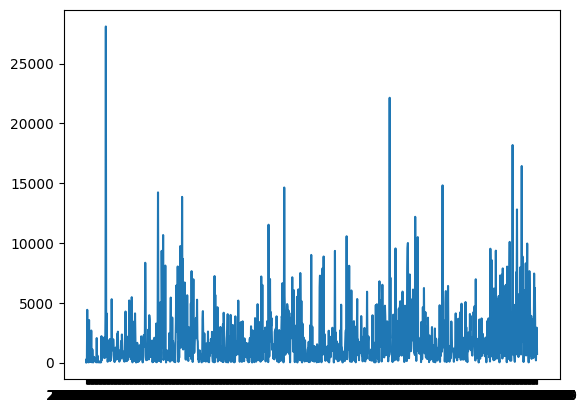

In [14]:
# trend.plot()
plt.plot(trend)

In [ ]:
# to hsow the the dsitribution overtime wewill 
# con vet teh data in datae time fromat to extract the proper year from it 
df['order_date'] = pd.to_datetime(df['order_date'])

In [17]:
df['year'] = df['order_date'].dt.year

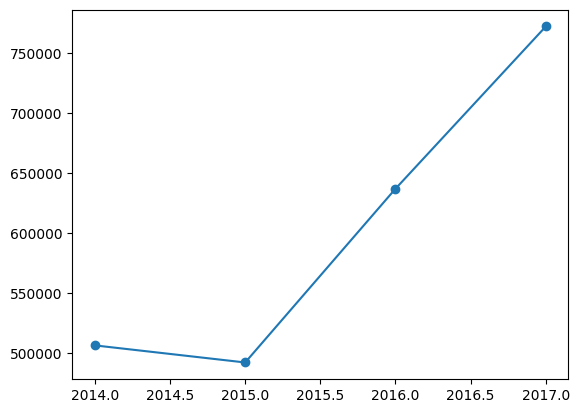

In [46]:
trend = df.groupby('year')['sales'].sum().sort_index()

plt.plot(trend , marker ='o')

# sort_index() sorts a Pandas object based on its index values.
# it will make sure that the year are in proer order 14,15,16....

<Axes: xlabel='year_month'>

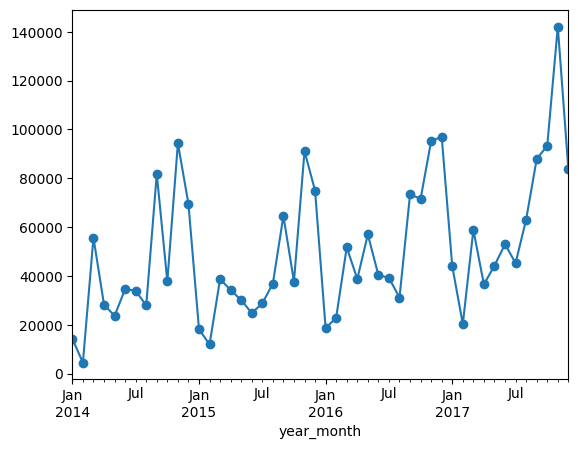

In [51]:
# Convert to datetime if you haven't already
df['order_date'] = pd.to_datetime(df['order_date'])

# Extract Year-Month (e.g., 2014-01, 2014-02)
df['year_month'] = df['order_date'].dt.to_period('M')

# Group by the new year_month column
monthly_trend = df.groupby('year_month')['sales'].sum()

# Plotting (making the figure wider so the dates don't overlap)
# plt.figure(figsize=(12, 5))
# monthly_trend.plot(kind='line', marker='o', color='b')
# plt.title('Monthly Revenue Growth (Notice the Q4 Spikes!)')
# plt.ylabel('Total Sales (INR)')
# plt.xlabel('Month')
# # plt.grid(True, linestyle='--', alpha=0.6)
# plt.show()
monthly_trend.plot(marker='o')

 # Which region yields the highest profit margins? (Visualizing geographical performance).

A profit margin is:

Profit Margin=
(Sales/Profit)×100

You're currently plotting total profit, not profit margin.

<Axes: xlabel='region', ylabel='profit'>

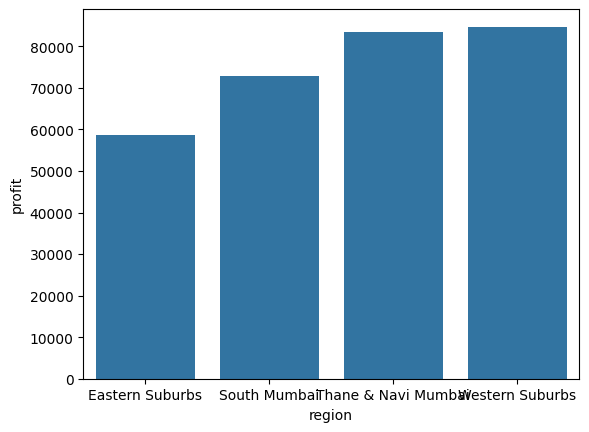

In [40]:
import matplotlib.pyplot as plt 
import seaborn as sns 

profitable = df.groupby('region')['profit'].sum()
sns.barplot(profitable)


# for profit by margin 



region
Eastern Suburbs        10.002833
South Mumbai           11.266542
Thane & Navi Mumbai    14.123095
Western Suburbs        14.551178
dtype: float64


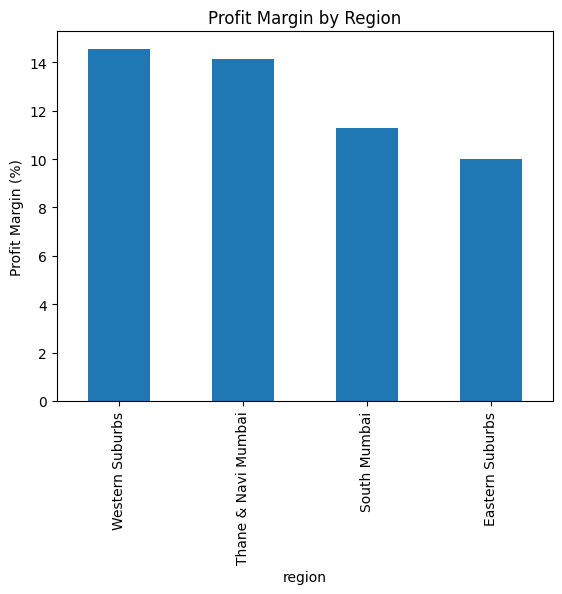

In [44]:
sales = df.groupby('region')['sales'].sum()
profit = df.groupby('region')['profit'].sum()

profit_margin = (profit / sales) * 100

print(profit_margin)


# plot 
profit_margin.sort_values(ascending=False).plot(
    kind='bar',
    title='Profit Margin by Region'
)

plt.ylabel('Profit Margin (%)')
plt.show()



# What are the top 5 highest-grossing sub-categories? (Visualizing product performance).

<Axes: xlabel='sub_category', ylabel='sales'>

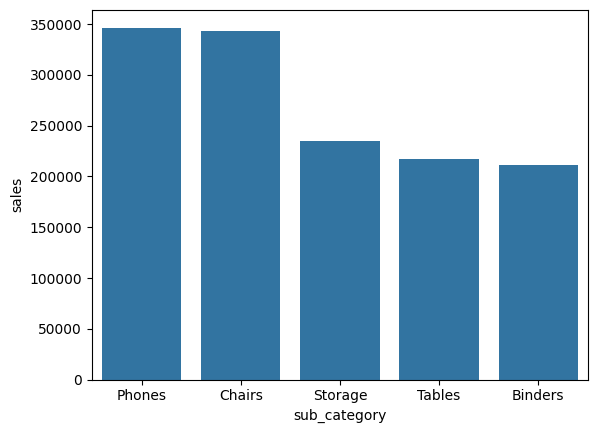

In [32]:
topgrossing = df.groupby('sub_category')['sales'].sum().sort_values(ascending=False).head(5)
# plt.plot(topgrossing)
sns.barplot(topgrossing)